# Validation of the unitary CA3→CA1 synapse at `apical_dendrite[9]`


## Synapse model

An `Exp2Syn` point process (conductance in pS, one `NetCon` event per vesicle) on
`apical_dendrite[9]` (stratum radiatum, ~249 µm from soma), read out by a single somatic
`SEClamp`.

In [1]:
# =============================================================================
# Imports, model, configuration
# =============================================================================
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PSM = Path("/data/hdrive/phd/AD-presynaptic-calcium-model/postsynaptic_model")
if str(PSM) not in sys.path:
    sys.path.insert(0, str(PSM))

import epsc_worker as W
from plot_config import apply_style, strip_spines, label_panel, PALETTE, DPI, save_figure
apply_style()

os.chdir(W.MECH_DIR)
os.environ["NEURON_MODULE_OPTIONS"] = "-nogui -NSTACK 100000 -NFRAME 20000"
from neuron import h
assert h.load_file(W.MODEL_FILE), "Failed to load the Poirazi CA1 model."

CFG = dict(W.DEFAULT_CFG)          # edit in epsc_worker.py, not here
DT  = CFG["dt"]
h.dt, h.celsius = DT, CFG["celsius"]

FIGDIR = Path("/data/hdrive/phd/AD-presynaptic-calcium-model/figures/outputs"); FIGDIR.mkdir(exist_ok=True)
CACHE  = FIGDIR / "fig8_poirazi_synapse_validation_data.npz"

h.distance(0, h.soma[0](0.5))
SEC  = h.apical_dendrite[CFG["syn_sec_index"]]
X    = CFG["syn_seg_x"]
DIST = h.distance(SEC(X))
VH, TEV = CFG["v_hold"], 100.0

print(f"NEURON {h.nrnversion()}   celsius {h.celsius} C   dt {DT} ms")
print(f"synapse   : apical_dendrite[{CFG['syn_sec_index']}]  {DIST:.1f} um from soma, "
      f"diam {SEC.diam:.2f} um, nseg {SEC.nseg}")
print(f"            g = {CFG['g_unitary_pS']:.0f} pS, tau1 {CFG['tau_rise']} / "
      f"tau2 {CFG['tau_decay']} ms, E = {CFG['e_ampa']} mV")
print(f"electrode : soma[{CFG['soma_sec']}], Vhold {VH} mV, Rs {CFG['series_r']} MOhm")

	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
object ExperimentControl created.

	1 
	0 
	0 
	1 
	0 
	1 
	0 
	0 
xopen("../../lib/vector-distance.hoc")
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
Opening cell setup
	19 
	1 
	0 
Opened. Setting up cell
	24 
xopen("../../lib/cut-sections.hoc")
	1 
xopen("../../lib/map-segments-to-3d.hoc")
	1 
xopen("../../lib/current-balance.hoc")
	1 
Balancing each compartment to -70 mV
NEURON NEURON -- VERSION 8.2.6 HEAD (078a34a9d) 2024-07-24   celsius 34.0 C   dt 0.025 ms
synapse   : apical_dendrite[9]  248.6 um from soma, diam 0.80 um, nseg 3
            g = 383 pS, tau1 0.2 / tau2 4.4 ms, E = 0.0 mV
electrode : soma[1], Vhold -70.0 mV, Rs 10.0 MOhm


## Experimental reference values

Recordings at the **CA3 → CA1 Schaffer-collateral synapse**, dendritic patch, −70 mV.

| Quantity | Proximal (100–140 µm) | Distal (240–280 µm) |
|---|---|---|
| Unitary AMPA EPSC | 11.0 ± 1.1 pA | **26.8 ± 2.0 pA** |
| Rise time constant | 169 ± 10 µs | **184 ± 6 µs** |
| Decay time constant | 5.9 ± 0.2 ms | **4.4 ± 0.3 ms** |

Smith MA, Ellis-Davies GCR, Magee JC (2003), *J Physiol* **548**(1):245–258.

`apical_dendrite[9]` sits at ~249 µm, inside the **distal** group, so the distal values are the
matched targets.
Derived conductance target: 26.8 pA / 70 mV ≈ **383 pS**.

In [ ]:
# =============================================================================
# Experimental reference values, as data
# =============================================================================
SMITH = dict(amp=26.8, amp_e=2.0,      # pA,  240-280 um
             rise=184., rise_e=6.,     # us
             dec=4.4,  dec_e=0.3)      # ms
SMITH["g_pS"] = SMITH["amp"] / abs(VH) * 1000

# Series resistance range\
RS_EXPERIMENTAL = (10., 30.)           # MOhm, Smith et al. 2003 Methods

print(f"target dendritic EPSC : {SMITH['amp']} +/- {SMITH['amp_e']} pA")
print(f"target rise / decay   : {SMITH['rise']:.0f} +/- {SMITH['rise_e']:.0f} us  /  "
      f"{SMITH['dec']} +/- {SMITH['dec_e']} ms")
print(f"implied conductance   : {SMITH['g_pS']:.0f} pS   (config uses "
      f"{CFG['g_unitary_pS']:.0f} pS)")

target dendritic EPSC : 26.8 +/- 2.0 pA
target rise / decay   : 184 +/- 6 us  /  4.4 +/- 0.3 ms
implied conductance   : 383 pS   (config uses 383 pS)


In [ ]:
# =============================================================================
# Helpers: build the synapse + electrode, run one trial, measure the EPSC
# =============================================================================

_S = {}

def build(g_pS=None, tau2=None):
    syn = h.Exp2Syn(SEC(X))
    syn.tau1 = CFG["tau_rise"]
    syn.tau2 = CFG["tau_decay"] if tau2 is None else tau2
    syn.e    = CFG["e_ampa"]
    nc = h.NetCon(None, syn)                       # Exp2Syn: peak g == weight (uS)
    nc.weight[0] = (CFG["g_unitary_pS"] if g_pS is None else g_pS) * 1e-6
    nc.delay = 0.0
    _S.update(syn=syn, nc=nc)
    return syn, nc

def run(events, tstop, rs=None):
    """One trial. Returns dict of arrays; currents in pA, conductance in pS."""
    rs = CFG["series_r"] if rs is None else rs
    clamp = h.SEClamp(h.soma[CFG["soma_sec"]](0.5))
    clamp.dur1, clamp.amp1, clamp.rs = tstop, VH, rs
    clamp.dur2 = clamp.dur3 = 0
    ev = np.atleast_1d(events).astype(float)
    nc = _S["nc"]
    _S["fih"] = h.FInitializeHandler(lambda: [nc.event(float(t)) for t in ev])
    rec = {"t": h.Vector().record(h._ref_t),
           "iloc": h.Vector().record(_S["syn"]._ref_i),
           "isoma": h.Vector().record(clamp._ref_i),
           "g": h.Vector().record(_S["syn"]._ref_g),
           "vd": h.Vector().record(SEC(X)._ref_v)}
    h.finitialize(VH); h.continuerun(tstop)
    # np.asarray() on a NEURON Vector is a READ-ONLY view; np.array() copies.
    o = {k: np.array(v, dtype=float) for k, v in rec.items()}
    o["iloc"] *= 1e3; o["isoma"] *= 1e3; o["g"] *= 1e6
    del clamp
    return o

def measure(y, tev=TEV, win=250.):
    """Amplitude (negative = inward), 20-80% rise (ms), decay to 1/e (ms)."""
    b, e = int((tev - 5) / DT), int(tev / DT)
    e2 = min(int((tev + win) / DT), len(y) - 1)
    seg = y[e:e2] - y[b:e].mean()
    k = int(np.argmin(seg)); amp = seg[k]
    pre = seg[:k + 1]
    rise = (np.argmax(pre <= 0.8 * amp) - np.argmax(pre <= 0.2 * amp)) * DT
    post = seg[k:]
    dec = np.argmax(post > 0.3679 * amp) * DT if np.any(post > 0.3679 * amp) else np.nan
    return amp, rise, dec

print("helpers ready")

helpers ready


In [ ]:
if CACHE.exists():
    D = dict(np.load(CACHE))
    print(f"loaded cached {CACHE.name}")
else:
    D = {}
    # -- unitary EPSC waveform, production settings ---------------------------
    build(); o = run(TEV, 400.)
    sl = slice(int((TEV - 5) / DT), int((TEV + 50) / DT))
    D["wt"]   = o["t"][sl] - TEV
    D["wloc"] = o["iloc"][sl]
    D["wsom"] = o["isoma"][sl] - o["isoma"][int((TEV - 5) / DT)]
    D["loc"]  = np.array(measure(o["iloc"]))
    D["som"]  = np.array(measure(o["isoma"]))
    D["dv"]   = o["vd"].max() - VH
    print("1/3 unitary waveform")

    # -- conductance calibration ---------------------------------------------
    gs = np.linspace(50, 900, 20)
    amps = []
    for g in gs:
        build(g_pS=g)
        amps.append(run(TEV, TEV + 150.)["iloc"].min())
    D["cal_g"], D["cal_a"] = gs, -np.array(amps)
    print("2/3 conductance calibration")

    # -- series resistance ----------------------------------------------------
    build()
    rss = np.array([0.1, 2, 5, 10, 15, 20, 25, 30])
    rows = np.array([measure(run(TEV, 400., rs=r)["isoma"]) for r in rss])
    D["rs_v"], D["rs_a"] = rss, -rows[:, 0]
    D["rs_r"], D["rs_d"] = rows[:, 1], rows[:, 2]
    print("3/3 series resistance")

    D["dist"] = DIST
    np.savez_compressed(CACHE, **D)
    print(f"saved -> {CACHE.name}")

loaded cached fig8_poirazi_synapse_validation_data.npz


In [5]:
# =============================================================================
# Validation table
# =============================================================================
loc, som = D["loc"], D["som"]
rows = [("dendritic amplitude (pA)", -loc[0], SMITH["amp"],  SMITH["amp_e"]),
        ("dendritic rise 20-80% (us)", loc[1] * 1000, SMITH["rise"], SMITH["rise_e"]),
        ("dendritic decay 1/e (ms)", loc[2], SMITH["dec"],  SMITH["dec_e"])]

print(f"apical_dendrite[{CFG['syn_sec_index']}]  |  {float(D['dist']):.0f} um  |  "
      f"g = {CFG['g_unitary_pS']:.0f} pS, tau2 = {CFG['tau_decay']} ms\n")
print(f"{'quantity':30}{'model':>10}{'experiment':>18}{'ratio':>8}   within s.e.m.")
print("-" * 82)
for name, m, e, er in rows:
    ok = "yes" if abs(m - e) <= er else "no"
    print(f"{name:30}{m:>10.2f}{f'{e:.1f} +/- {er:.1f}':>18}{m / e:>8.3f}   {ok}")
print(f"\n{'somatic amplitude (pA)':30}{-som[0]:>10.2f}")
print(f"{'somatic rise 20-80% (ms)':30}{som[1]:>10.2f}")
print(f"{'somatic decay 1/e (ms)':30}{som[2]:>10.2f}")
print(f"{'somatic / dendritic':30}{som[0] / loc[0]:>10.2f}")
print(f"{'local depolarisation (mV)':30}{float(D['dv']):>10.2f}")

apical_dendrite[9]  |  249 um  |  g = 383 pS, tau2 = 4.4 ms

quantity                           model        experiment   ratio   within s.e.m.
----------------------------------------------------------------------------------
dendritic amplitude (pA)           26.23      26.8 +/- 2.0   0.979   yes
dendritic rise 20-80% (us)        200.00     184.0 +/- 6.0   1.087   no
dendritic decay 1/e (ms)            4.65       4.4 +/- 0.3   1.057   yes

somatic amplitude (pA)              7.99
somatic rise 20-80% (ms)            1.18
somatic decay 1/e (ms)             10.60
somatic / dendritic                 0.30
local depolarisation (mV)           1.82


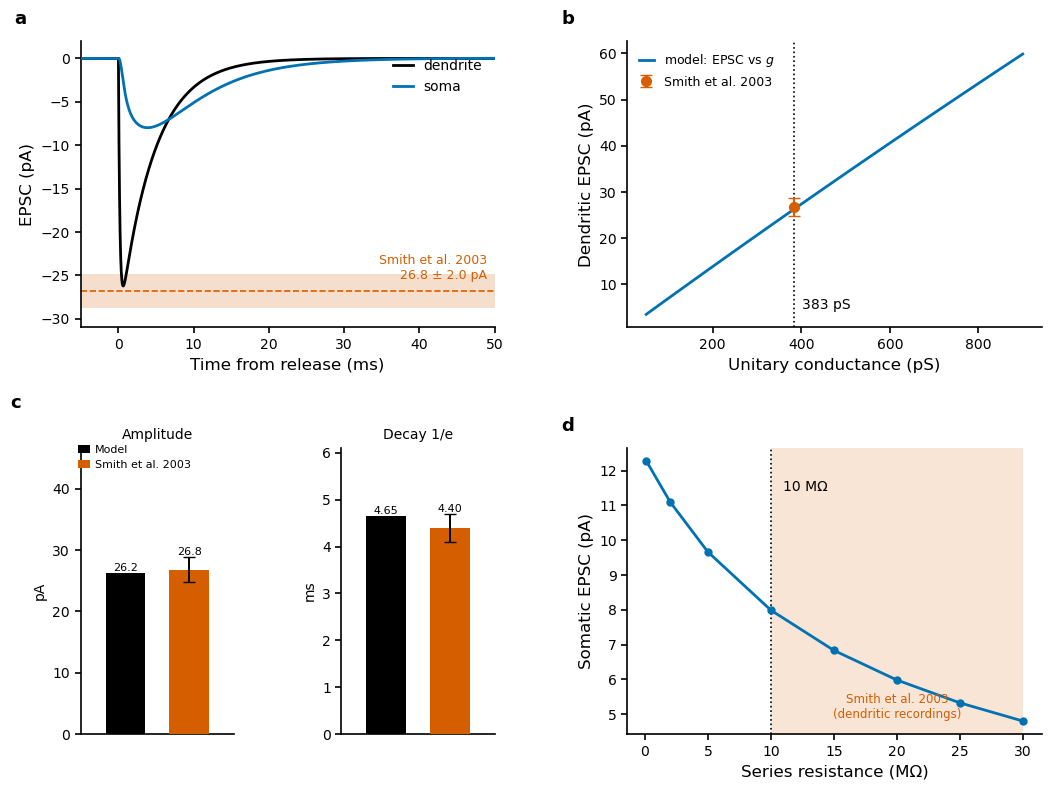

saved figures/ad9_validation.png and .pdf at 600 dpi


In [ ]:
# =============================================================================
# FIGURE -- 2x2 validation panel  ->  figures/ad9_validation.png / .pdf
# =============================================================================
DEND, SOMA, EXPT = PALETTE["black"], PALETTE["blue"], PALETTE["vermillion"]
gm, rsp = CFG["g_unitary_pS"], CFG["series_r"]

fig = plt.figure(figsize=(12.4, 9))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)
axa = fig.add_subplot(gs[0, 0])
axb = fig.add_subplot(gs[0, 1])
gsc = gs[1, 0].subgridspec(1, 2, wspace=0.70)     # one axis per unit
axc = [fig.add_subplot(gsc[0, i]) for i in range(2)]
axd = fig.add_subplot(gs[1, 1])

# ---- a: unitary EPSC waveform ----
p = axa
p.axhspan(-(SMITH["amp"] + SMITH["amp_e"]), -(SMITH["amp"] - SMITH["amp_e"]),
          color=EXPT, alpha=.20, lw=0, zorder=0)
p.plot(D["wt"], D["wloc"], color=DEND, lw=2.0, label="dendrite", zorder=3)
p.plot(D["wt"], D["wsom"], color=SOMA, lw=2.0, label="soma", zorder=3)
p.axhline(-SMITH["amp"], color=EXPT, lw=1.2, ls="--", zorder=1)
p.annotate("Smith et al. 2003\n26.8 ± 2.0 pA", (49, -SMITH["amp"] + 1.0),
           color=EXPT, fontsize=9, ha="right", va="bottom")     # above the dashed line
p.set_xlabel("Time from release (ms)"); p.set_ylabel("EPSC (pA)")
p.set_xlim(-5, 50); p.set_ylim(-31, 2)
p.legend(frameon=False, fontsize=10, loc="upper right", handlelength=1.4,
         bbox_to_anchor=(1.0, 0.98))

# ---- b: conductance calibration ----
p = axb
p.plot(D["cal_g"], D["cal_a"], color=SOMA, lw=2.0, zorder=2,
       label="model: EPSC vs $g$")
p.errorbar([gm], [SMITH["amp"]], yerr=[SMITH["amp_e"]], fmt="o", color=EXPT, ms=7,
           capsize=4, lw=1.6, zorder=4, label="Smith et al. 2003")
p.axvline(gm, color=DEND, ls=":", lw=1.2, zorder=1)
p.annotate(f"{gm:.0f} pS", (gm + 18, 4), color=DEND, fontsize=10, ha="left", va="bottom")
p.set_xlabel("Unitary conductance (pS)"); p.set_ylabel("Dendritic EPSC (pA)")
p.legend(frameon=False, fontsize=9, loc="upper left", handlelength=1.2)

# ---- c: model vs experiment, one axis per unit ----
specs = [("Amplitude", "pA", -loc[0], SMITH["amp"], SMITH["amp_e"], "{:.1f}"),
         ("Decay 1/e", "ms",  loc[2], SMITH["dec"], SMITH["dec_e"], "{:.2f}")]

for j, (q, (title, unit, m, e, er, fmt)) in enumerate(zip(axc, specs)):
    q.bar([0], [m], 0.62, color=DEND, zorder=3, label="Model")
    q.bar([1], [e], 0.62, yerr=[er], color=EXPT, capsize=4, zorder=3,
          error_kw=dict(lw=1.4), label="Smith et al. 2003")
    q.set_xticks([])
    q.set_xlim(-0.7, 1.7)
    q.set_ylim(0, max(m, e + er) * (1.62 if j == 0 else 1.30))
    q.set_ylabel(unit, fontsize=10)
    q.set_title(title, fontsize=10, pad=6)
    for xi, vi, ev in [(0, m, 0), (1, e, er)]:
        q.annotate(fmt.format(vi), (xi, vi + ev), ha="center", va="bottom",
                   fontsize=8, zorder=4)
    strip_spines(q)
axc[0].legend(frameon=False, fontsize=8, loc="upper left", handlelength=1.0,
              handletextpad=0.5, borderpad=0.0, bbox_to_anchor=(-0.05, 1.03))

# ---- d: recording electrode ----
p = axd
p.axvspan(*RS_EXPERIMENTAL, color=EXPT, alpha=.16, lw=0, zorder=0)
p.plot(D["rs_v"], D["rs_a"], "o-", color=SOMA, ms=5, lw=2.0, zorder=3)
p.axvline(rsp, color=DEND, ls=":", lw=1.2, zorder=1)
p.annotate(f"{rsp:.0f} MΩ", (rsp + 1, D["rs_a"].max() * .93), color=DEND, fontsize=10)
p.annotate("Smith et al. 2003\n(dendritic recordings)",
           (np.mean(RS_EXPERIMENTAL), D["rs_a"].min() * 1.02),
           ha="center", fontsize=8.5, color=EXPT)
p.set_xlabel("Series resistance (MΩ)"); p.set_ylabel("Somatic EPSC (pA)")

for q in (axa, axb, axd):
    strip_spines(q)
for q, lab in [(axa, "a"), (axb, "b"), (axd, "d")]:
    label_panel(q, lab, x=-0.16, y=1.06)
label_panel(axc[0], "c", x=-0.46, y=1.14)

save_figure(fig, str(FIGDIR / "fig8_poirazi_synapse_validation.png"), dpi=DPI)
save_figure(fig, str(FIGDIR / "fig8_poirazi_synapse_validation.pdf"), dpi=DPI)
plt.show()
print(f"saved figures/ad9_validation.png and .pdf at {DPI} dpi")